# 单谱宇宙射线清理对照

这个 notebook 只看单谱宇宙射线清理本身，不做 AsLS、不裁切、不插值、不做 group 兜底

展示内容：

1. 原始谱
2. narrow cleaned：局部 `median/MAD` 窄尖峰清理后
3. narrow + peak-morph cleaned：再按峰显著度、峰宽和显著度/宽度比清理后
4. 被 narrow 替换的点
5. 被 peak morphology 替换的峰区

默认从 `DATASET_NAME` 对应数据集的 `init` 目录里随机抽取一条原始谱。如果要固定单条样本，填 `SAMPLE_PATH`；如果要固定某个文件夹内随机抽样，填 `SAMPLE_FOLDER`


In [97]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import find_peaks, peak_prominences, peak_widths


def find_project_root(start=None):
    """从当前目录向上查找项目根目录，兼容从 notebooks/ 里启动"""
    current = Path(start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "raman").is_dir() and (path / "dataset").is_dir():
            return path
    return current


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

for name in list(sys.modules):
    if name == "raman" or name.startswith("raman."):
        del sys.modules[name]

from raman.data.build import COMMON_BAD_BANDS, DEFAULT_PIPELINE_CONFIG
from raman.data.offline import (
    _estimate_noise_from_diff,
    _median_filter_1d,
    _merge_intervals,
    _replace_segment,
    _residual_z_score,
)
from raman.data.profiles import get_dataset_dir, get_profile
from raman.data.spectrum import build_valid_mask, read_arc_data

sns.set_theme(style="whitegrid", context="talk", font="Microsoft YaHei")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["figure.figsize"] = (11, 5)

DATASET_NAME = "细菌"
SAMPLE_PATH = None  # 填文件路径时固定单条样本；None 时走随机抽样
SAMPLE_FOLDER = "init/Citrobacter/CITF03"  # 填相对文件夹时只在该文件夹内随机抽样；None 时用 init
SAMPLE_SEED = None  # 设为整数可复现随机抽样

profile = get_profile(DATASET_NAME)
dataset_dir = get_dataset_dir(profile, PROJECT_ROOT)
cfg = DEFAULT_PIPELINE_CONFIG
BAD_BANDS = COMMON_BAD_BANDS


def resolve_sample_path():
    if SAMPLE_PATH:
        path = Path(SAMPLE_PATH)
        if not path.is_absolute():
            path = PROJECT_ROOT / path
        if not path.is_file():
            raise FileNotFoundError(f"样本不存在：{path}")
        return path

    if SAMPLE_FOLDER:
        root = Path(SAMPLE_FOLDER)
        if not root.is_absolute():
            root = dataset_dir / root
    else:
        root = dataset_dir / profile.root_init

    matches = sorted(root.rglob("*.arc_data"))
    if not matches:
        raise FileNotFoundError(f"未找到 .arc_data：{root}")
    return random.Random(SAMPLE_SEED).choice(matches)


def add_bad_band_spans(ax, bad_bands, label="bad bands"):
    if getattr(ax, "_bad_band_spans_added", False):
        return
    for idx, (band_min, band_max) in enumerate(bad_bands):
        ax.axvspan(
            band_min,
            band_max,
            color="gray",
            alpha=0.15,
            label=label if idx == 0 else None,
        )
    ax._bad_band_spans_added = True


def plot_without_bad_bands(ax, wn, sp, bad_bands, **kwargs):
    """坏段位置断线，只保留灰色 mask"""
    sp_plot = np.asarray(sp, dtype=np.float32).copy()
    keep_mask = build_valid_mask(np.asarray(wn), bad_bands)
    if keep_mask is not None:
        sp_plot[~keep_mask] = np.nan
    return ax.plot(wn, sp_plot, **kwargs)


def style_axis(ax, title, ylabel="Intensity"):
    add_bad_band_spans(ax, BAD_BANDS)
    ax.set_title(title)
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")

In [98]:
def run_cosmic_cleanup_trace(wn, sp, valid_mask, cfg):
    """按库内清理逻辑执行 narrow + peak morphology，并记录被替换的位置"""
    raw = np.asarray(sp, dtype=np.float32)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    narrow_clean = raw.copy()
    narrow_mask = np.zeros(raw.shape, dtype=bool)
    narrow_iter_masks = []

    for _ in range(int(cfg.cosmic_ray_max_iter)):
        local_median = _median_filter_1d(narrow_clean, cfg.cosmic_ray_window)
        residual = narrow_clean - local_median
        z_score = _residual_z_score(residual, valid_mask)
        if z_score is None:
            break

        spike_mask = valid_mask & (z_score > float(cfg.cosmic_ray_threshold))
        if not spike_mask.any():
            break

        narrow_iter_masks.append(spike_mask.copy())
        narrow_mask |= spike_mask
        narrow_clean[spike_mask] = local_median[spike_mask]

    peak_clean = narrow_clean.copy()
    peak_mask = np.zeros(raw.shape, dtype=bool)
    peak_segments = []
    noise = _estimate_noise_from_diff(peak_clean, valid_mask)

    peaks, _ = find_peaks(peak_clean)
    peaks = peaks[valid_mask[peaks]]
    if noise > 1e-8 and peaks.size > 0:
        prominences = peak_prominences(peak_clean, peaks)[0]
        widths, _, left_ips, right_ips = peak_widths(
            peak_clean,
            peaks,
            rel_height=float(cfg.cosmic_ray_peak_rel_height),
        )
        step = float(np.median(np.diff(wn)))
        step = max(abs(step), 1e-6)
        width_cm = widths * step
        prominence_z = prominences / noise
        ratio = prominence_z / np.maximum(width_cm, step)
        selected = (
            (prominence_z >= float(cfg.cosmic_ray_peak_prominence_z))
            & (width_cm <= float(cfg.cosmic_ray_peak_width_max_cm))
            & (ratio >= float(cfg.cosmic_ray_peak_ratio_z_per_cm))
        )

        fallback = _median_filter_1d(peak_clean, 7)
        candidates = []
        for peak, left_ip, right_ip, prom_z, width, ratio_value in zip(
            peaks[selected],
            left_ips[selected],
            right_ips[selected],
            prominence_z[selected],
            width_cm[selected],
            ratio[selected],
        ):
            start = max(0, int(np.floor(left_ip)) - int(cfg.cosmic_ray_peak_pad_points))
            end = min(peak_clean.size, int(np.ceil(right_ip)) + int(cfg.cosmic_ray_peak_pad_points) + 1)
            if start < end:
                candidates.append(
                    {
                        "start": start,
                        "end": end,
                        "peak": int(peak),
                        "width_cm": float(width),
                        "prominence_z": float(prom_z),
                        "ratio": float(ratio_value),
                    }
                )

        for start, end in _merge_intervals((item["start"], item["end"]) for item in candidates):
            segment_mask = np.zeros(peak_clean.shape, dtype=bool)
            segment_mask[start:end] = True
            segment_mask &= valid_mask
            if not segment_mask.any():
                continue

            start_idx = int(np.where(segment_mask)[0][0])
            end_idx = int(np.where(segment_mask)[0][-1]) + 1
            before = peak_clean[start_idx:end_idx].copy()
            _replace_segment(peak_clean, fallback, start_idx, end_idx, valid_mask)
            peak_mask[start_idx:end_idx] = True
            related = [
                item for item in candidates
                if item["start"] < end_idx and item["end"] > start_idx
            ]
            peak_segments.append(
                {
                    "start": start_idx,
                    "end": end_idx,
                    "wn_min": float(wn[start_idx]),
                    "wn_max": float(wn[end_idx - 1]),
                    "width_points": int(end_idx - start_idx),
                    "width_cm": float(max(item["width_cm"] for item in related)),
                    "prominence_z": float(max(item["prominence_z"] for item in related)),
                    "ratio": float(max(item["ratio"] for item in related)),
                    "delta_mean": float(np.mean(before - peak_clean[start_idx:end_idx])),
                }
            )

    return {
        "raw": raw,
        "narrow_clean": narrow_clean,
        "peak_clean": peak_clean,
        "narrow_mask": narrow_mask,
        "narrow_iter_masks": narrow_iter_masks,
        "peak_mask": peak_mask,
        "peak_segments": peak_segments,
        "noise": noise,
    }


sample_path = resolve_sample_path()
wn, sp = read_arc_data(sample_path)
if wn.size == 0 or sp.size == 0:
    raise ValueError(f"读取失败：{sample_path}")

valid_mask_raw = build_valid_mask(wn, BAD_BANDS)
if valid_mask_raw is None:
    valid_mask_raw = np.ones_like(wn, dtype=bool)

trace = run_cosmic_cleanup_trace(wn, sp, valid_mask_raw, cfg)

print(f"project_root = {PROJECT_ROOT}")
print(f"dataset_dir = {dataset_dir}")
print(f"sample_path = {sample_path}")
print(f"bad_bands = {BAD_BANDS}")
print(f"narrow: window={cfg.cosmic_ray_window}, threshold={cfg.cosmic_ray_threshold}, max_iter={cfg.cosmic_ray_max_iter}")
print(
    "peak morphology: "
    f"prominence_z>={cfg.cosmic_ray_peak_prominence_z}, "
    f"width_cm<={cfg.cosmic_ray_peak_width_max_cm}, "
    f"ratio>={cfg.cosmic_ray_peak_ratio_z_per_cm}, "
    f"pad={cfg.cosmic_ray_peak_pad_points}"
)
print(f"noise scale = {trace['noise']:.6f}")
print(f"narrow 替换点数: {int(trace['narrow_mask'].sum())}")
print(f"peak morphology 替换点数: {int(trace['peak_mask'].sum())}")
print(f"peak morphology 片段数: {len(trace['peak_segments'])}")

project_root = E:\Pythonproject\拉曼光谱分类
dataset_dir = E:\Pythonproject\拉曼光谱分类\dataset\细菌
sample_path = E:\Pythonproject\拉曼光谱分类\dataset\细菌\init\Citrobacter\CITF03\cell12_Area01_001_shift.arc_data
bad_bands = ((890.0, 950.0),)
narrow: window=7, threshold=7.0, max_iter=2
peak morphology: prominence_z>=8.0, width_cm<=15.0, ratio>=2.0, pad=1
noise scale = 30.402339
narrow 替换点数: 6
peak morphology 替换点数: 20
peak morphology 片段数: 2


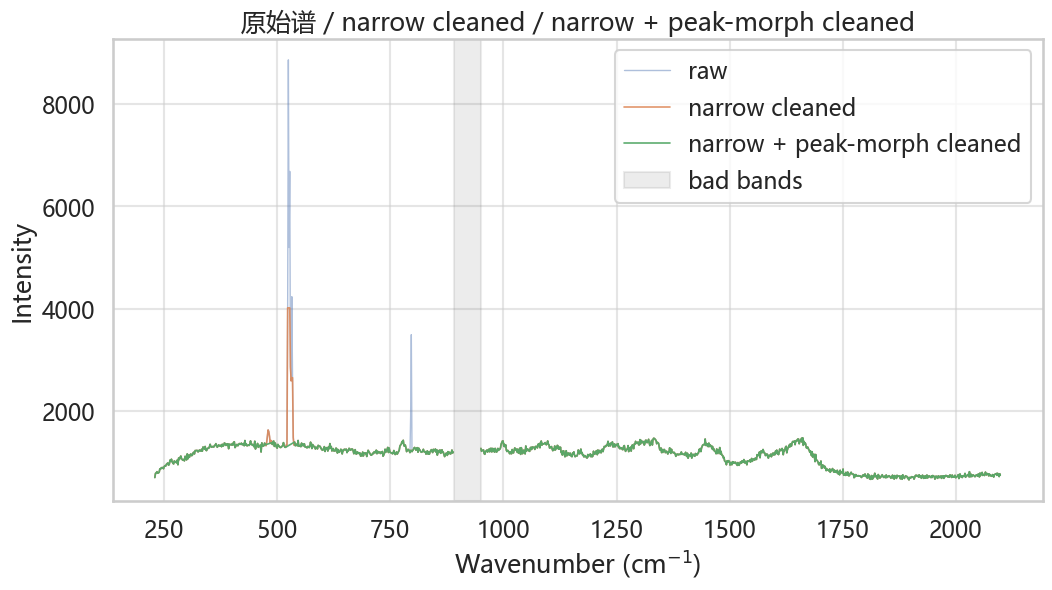

In [99]:
# 三条曲线总览：原始谱、narrow cleaned、narrow + peak-morph cleaned
fig, ax = plt.subplots(figsize=(12, 6))
plot_without_bad_bands(ax, wn, trace["raw"], BAD_BANDS, label="raw", alpha=0.45, linewidth=1.0)
plot_without_bad_bands(ax, wn, trace["narrow_clean"], BAD_BANDS, label="narrow cleaned", alpha=0.85, linewidth=1.2)
plot_without_bad_bands(ax, wn, trace["peak_clean"], BAD_BANDS, label="narrow + peak-morph cleaned", alpha=0.95, linewidth=1.2)
style_axis(ax, "原始谱 / narrow cleaned / narrow + peak-morph cleaned")
plt.show()

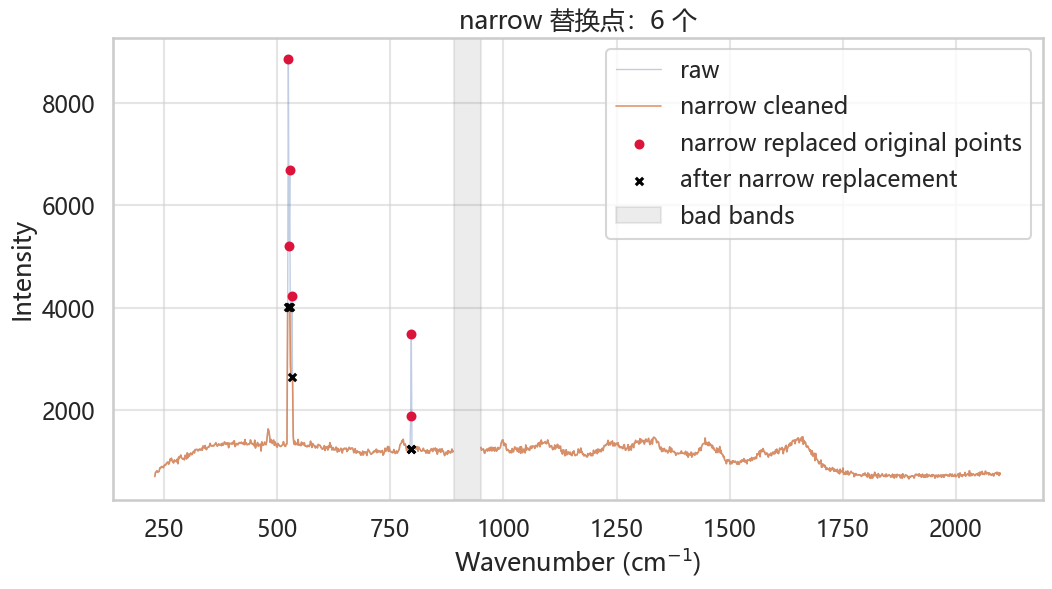

In [100]:
# 被 narrow 替换的点
fig, ax = plt.subplots(figsize=(12, 6))
plot_without_bad_bands(ax, wn, trace["raw"], BAD_BANDS, label="raw", alpha=0.35, linewidth=1.0)
plot_without_bad_bands(ax, wn, trace["narrow_clean"], BAD_BANDS, label="narrow cleaned", alpha=0.85, linewidth=1.2)

mask = trace["narrow_mask"]
if mask.any():
    ax.scatter(
        wn[mask],
        trace["raw"][mask],
        s=32,
        color="crimson",
        label="narrow replaced original points",
        zorder=5,
    )
    ax.scatter(
        wn[mask],
        trace["narrow_clean"][mask],
        s=28,
        marker="x",
        color="black",
        label="after narrow replacement",
        zorder=6,
    )
else:
    ax.text(0.02, 0.92, "当前样本没有 narrow 替换点", transform=ax.transAxes)

style_axis(ax, f"narrow 替换点：{int(mask.sum())} 个")
plt.show()

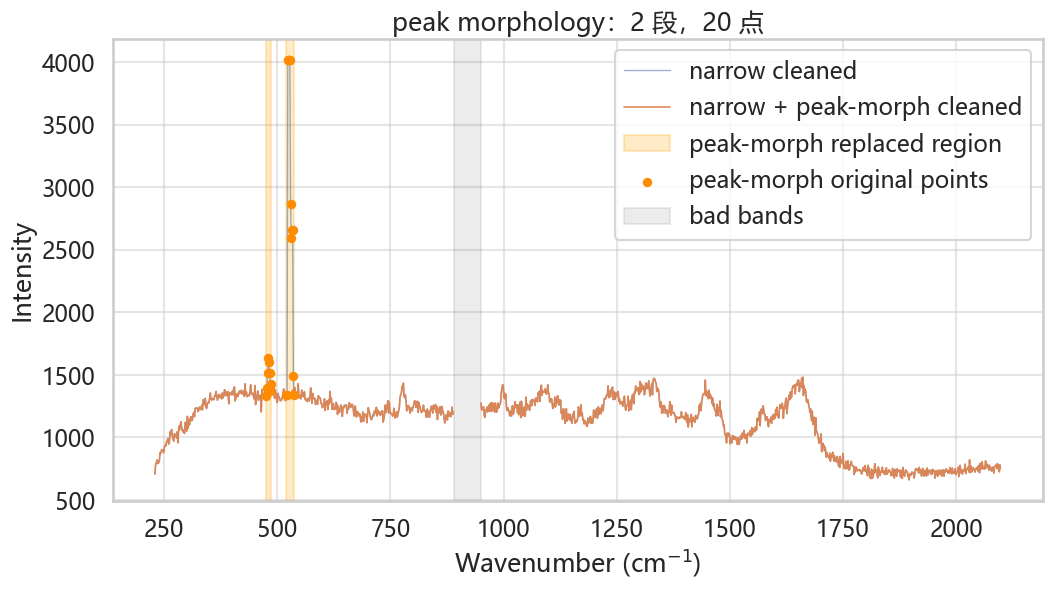

peak morphology 片段明细：
01. wn=475.36-486.19, width_cm=5.41, prominence_z=11.71, ratio=2.16, delta_mean=109.25
02. wn=520.14-537.06, width_cm=10.95, prominence_z=108.94, ratio=9.95, delta_mean=1348.08


In [101]:
# 被 peak morphology 替换的峰区
fig, ax = plt.subplots(figsize=(12, 6))
plot_without_bad_bands(ax, wn, trace["narrow_clean"], BAD_BANDS, label="narrow cleaned", alpha=0.55, linewidth=1.0)
plot_without_bad_bands(ax, wn, trace["peak_clean"], BAD_BANDS, label="narrow + peak-morph cleaned", alpha=0.95, linewidth=1.2)

for idx, seg in enumerate(trace["peak_segments"]):
    ax.axvspan(
        seg["wn_min"],
        seg["wn_max"],
        color="orange",
        alpha=0.22,
        label="peak-morph replaced region" if idx == 0 else None,
    )

mask = trace["peak_mask"]
if mask.any():
    ax.scatter(
        wn[mask],
        trace["narrow_clean"][mask],
        s=28,
        color="darkorange",
        label="peak-morph original points",
        zorder=5,
    )
else:
    ax.text(0.02, 0.92, "当前样本没有 peak morphology 替换峰区", transform=ax.transAxes)

style_axis(ax, f"peak morphology：{len(trace['peak_segments'])} 段，{int(mask.sum())} 点")
plt.show()

if trace["peak_segments"]:
    print("peak morphology 片段明细：")
    for idx, seg in enumerate(trace["peak_segments"], start=1):
        print(
            f"{idx:02d}. wn={seg['wn_min']:.2f}-{seg['wn_max']:.2f}, "
            f"width_cm={seg['width_cm']:.2f}, prominence_z={seg['prominence_z']:.2f}, "
            f"ratio={seg['ratio']:.2f}, delta_mean={seg['delta_mean']:.2f}"
        )

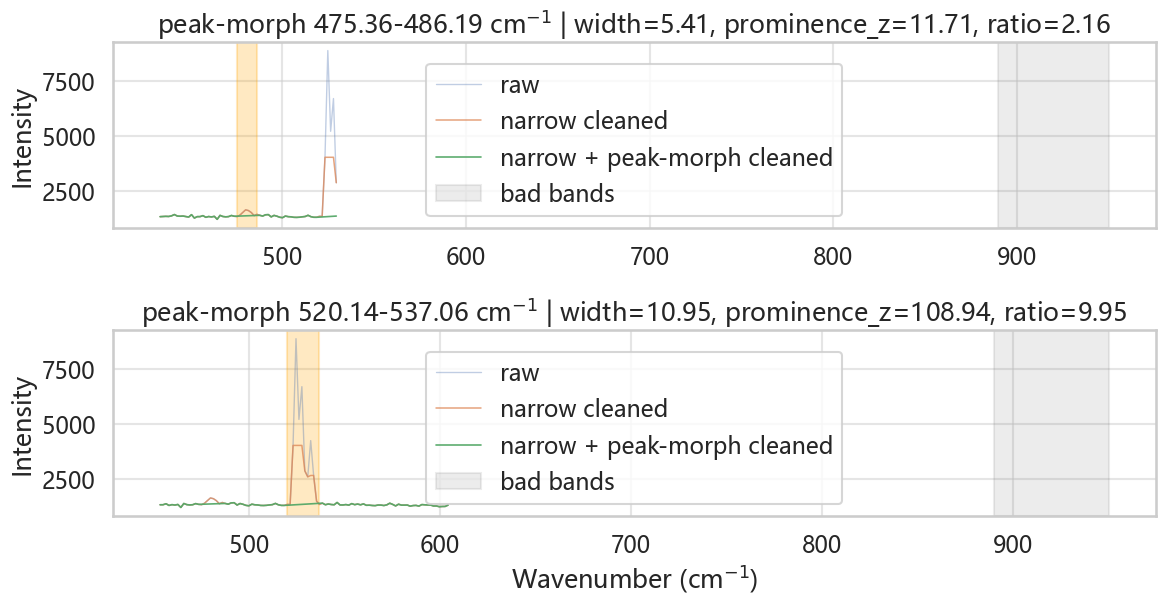

In [102]:
# peak morphology 片段局部放大，默认最多展示前 6 段
segments = trace["peak_segments"][:6]
if not segments:
    print("当前样本没有 peak morphology 片段可放大")
else:
    fig, axes = plt.subplots(len(segments), 1, figsize=(12, 3.2 * len(segments)), squeeze=False)
    axes = axes[:, 0]
    for ax, seg in zip(axes, segments):
        pad = max((seg["wn_max"] - seg["wn_min"]) * 4, 20.0)
        left = seg["wn_min"] - pad
        right = seg["wn_max"] + pad
        local = (wn >= left) & (wn <= right)

        ax.plot(wn[local], trace["raw"][local], label="raw", alpha=0.35, linewidth=1.0)
        ax.plot(wn[local], trace["narrow_clean"][local], label="narrow cleaned", alpha=0.75, linewidth=1.1)
        ax.plot(wn[local], trace["peak_clean"][local], label="narrow + peak-morph cleaned", alpha=0.95, linewidth=1.2)
        ax.axvspan(seg["wn_min"], seg["wn_max"], color="orange", alpha=0.24)
        add_bad_band_spans(ax, BAD_BANDS)
        ax.set_title(
            f"peak-morph {seg['wn_min']:.2f}-{seg['wn_max']:.2f} cm$^{{-1}}$ | "
            f"width={seg['width_cm']:.2f}, prominence_z={seg['prominence_z']:.2f}, ratio={seg['ratio']:.2f}"
        )
        ax.set_ylabel("Intensity")
        ax.legend(loc="best")

    axes[-1].set_xlabel("Wavenumber (cm$^{-1}$)")
    plt.tight_layout()
    plt.show()